<a href="https://colab.research.google.com/github/Syed07Asif/Syed07Asif-Brain_tumor_Classification-DEEPLEARNING/blob/main/Brain_tumor_classification_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi
!pip install torch torchvision torchaudio timm matplotlib scikit-learn opencv-python grad-cam


Fri Oct 24 09:04:06 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
from google.colab import files
uploaded = files.upload()


Saving brain_tumor_classification.zip to brain_tumor_classification.zip


In [5]:
import zipfile
import os

zip_path = "/content/brain_tumor_classification.zip"
extract_path = "/content/brain_tumor_classification"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
os.listdir(extract_path)


Dataset extracted successfully!


['Testing', 'Training']

In [6]:
import os
import cv2
import numpy as np
from tqdm import tqdm

train_dir = "/content/brain_tumor_classification/Training"
test_dir = "/content/brain_tumor_classification/Testing"

categories = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
IMG_SIZE = 128

def load_data(data_dir):
    data = []
    for category in categories:
        path = os.path.join(data_dir, category)
        label = categories.index(category)
        for img_name in tqdm(os.listdir(path), desc=f"Loading {category}"):
            try:
                img_path = os.path.join(path, img_name)
                img = cv2.imread(img_path)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                data.append([img, label])
            except Exception as e:
                pass
    return np.array(data, dtype=object)

train_data = load_data(train_dir)
test_data = load_data(test_dir)

print(f" Training samples: {len(train_data)}")
print(f" Testing samples: {len(test_data)}")


Loading pituitary_tumor: 100%|██████████| 74/74 [00:00<00:00, 368.69it/s]

 Training samples: 2870
 Testing samples: 394


In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import os
import numpy as np
import matplotlib.pyplot as plt


In [8]:
dataset_path = "/content/brain_tumor_classification"
img_height, img_width = 224, 224
batch_size = 32


In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 2612 images belonging to 2 classes.
Found 652 images belonging to 2 classes.


In [10]:
num_classes = len(train_generator.class_indices)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 111, 111, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 54, 54, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,114 (42.61 MB)

 Trainable params: 11,169,666 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_brain_tumor_model.h5", save_best_only=True)
]


In [12]:
epochs = 35

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.8222 - loss: 0.8423

82/82 ━━━━━━━━━━━━━━━━━━━━ 63s 633ms/step - accuracy: 0.8225 - loss: 0.8394 - val_accuracy: 0.8804 - val_loss: 0.3369
Epoch 2/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 43s 516ms/step - accuracy: 0.8829 - loss: 0.3667 - val_accuracy: 0.8804 - val_loss: 0.4613
Epoch 3/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 42s 511ms/step - accuracy: 0.8750 - loss: 0.3759 - val_accuracy: 0.8804 - val_loss: 0.4461
Epoch 4/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 43s 523ms/step - accuracy: 0.8718 - loss: 0.3478 - val_accuracy: 0.8804 - val_loss: 0.4490
Epoch 5/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 42s 510ms/step - accuracy: 0.8728 - loss: 0.3448 - val_accuracy: 0.8819 - val_loss: 0.3902
Epoch 6/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.8751 - loss: 0.3272

82/82 ━━━━━━━━━━━━━━━━━━━━ 43s 527ms/step - accuracy: 0.8751 - loss: 0.3273 - val_accuracy: 0.8850 - val_loss: 0.2678
Epoch 7/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 43s 521ms/step - accuracy: 0.8811 - loss: 0.3291 - val_accuracy: 0.8804 - val_loss: 0.2996
Epoch 8/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.8817 - loss: 0.3159

82/82 ━━━━━━━━━━━━━━━━━━━━ 42s 517ms/step - accuracy: 0.8816 - loss: 0.3161 - val_accuracy: 0.8880 - val_loss: 0.2536
Epoch 9/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.8775 - loss: 0.3087

82/82 ━━━━━━━━━━━━━━━━━━━━ 43s 520ms/step - accuracy: 0.8776 - loss: 0.3087 - val_accuracy: 0.8850 - val_loss: 0.2480
Epoch 10/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 42s 509ms/step - accuracy: 0.8694 - loss: 0.3198 - val_accuracy: 0.8834 - val_loss: 0.2859
Epoch 11/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 43s 524ms/step - accuracy: 0.8740 - loss: 0.3125 - val_accuracy: 0.8850 - val_loss: 0.2999
Epoch 12/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 42s 510ms/step - accuracy: 0.8842 - loss: 0.2964 - val_accuracy: 0.8988 - val_loss: 0.2484
Epoch 13/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 43s 529ms/step - accuracy: 0.8945 - loss: 0.3242 - val_accuracy: 0.8957 - val_loss: 0.2545
Epoch 14/35
82/82 ━━━━━━━━━━━━━━━━━━━━ 41s 507ms/step - accuracy: 0.8705 - loss: 0.3167 - val_accuracy: 0.8880 - val_loss: 0.3077


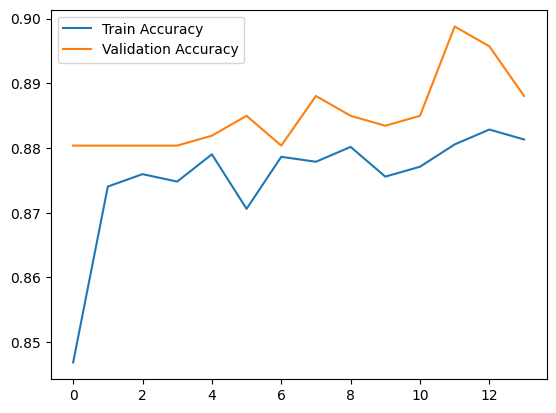

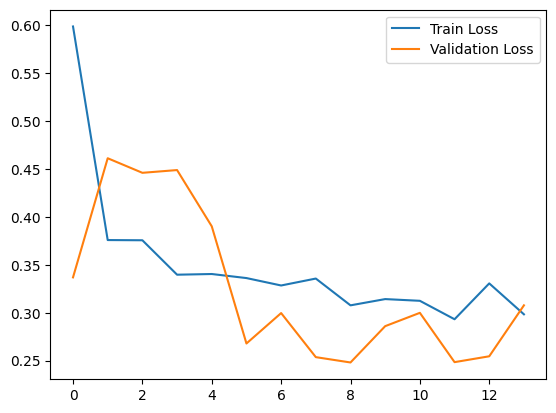

In [13]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()


Saving testimage-2.jpg to testimage-2.jpg

 Image uploaded: testimage-2.jpg
Detected class labels: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

 Predicted class: meningioma_tumor

 Confidence: 57.45%


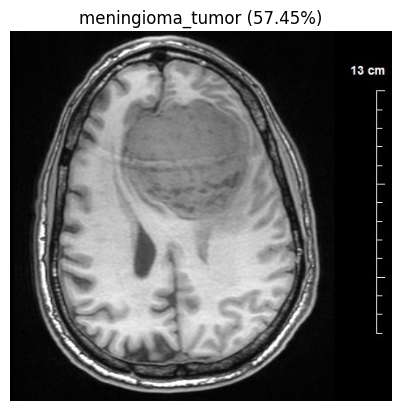

In [14]:
from tensorflow.keras.preprocessing import image
import numpy as np
import os
from google.colab import files
import matplotlib.pyplot as plt

uploaded = files.upload()

for filename in uploaded.keys():
    img_path = '/content/' + filename
    print(f"\n Image uploaded: {filename}")

dataset_path = "/content/brain_tumor_classification/Training"

class_labels = sorted(os.listdir(dataset_path))
print("Detected class labels:", class_labels)

img = image.load_img(img_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

pred = model.predict(img_array)
class_idx = np.argmax(pred)
confidence = np.max(pred)

predicted_label = class_labels[class_idx]
print(f"\n Predicted class: {predicted_label}")
print(f"\n Confidence: {confidence*100:.2f}%")

plt.imshow(image.load_img(img_path))
plt.title(f"{predicted_label} ({confidence*100:.2f}%)")
plt.axis('off')
plt.show()

